In [ ]:
## Analysis of inflow outputs for renal cell carcinoma dataset
## Dr Daniyal Jafree, Lotfollahi Group, CellGen Programme, Wellcome Sanger Institute
## Validation for pertubation experiment - derivation of ICB-like T cell subset with replacement of other T cells within TLS region
## Final Version - 20th July 2025

In [1]:
## Load required packages

import os, sys
import yaml
import mintflow
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm
import numpy as np
import anndata

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import gseapy as gp
from gseapy.plot import barplot

import mintflow
import mintflow.interface.perturbation.module_gen_micsizefactor
import mintflow.interface.perturbation.module_gen_stdata

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/nfs/team361/aa36/OnGit/inflow/src/mintflow/utils_pyg.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covar

In [2]:
## Set paths

path_anndata = '/nfs/team361/aa36/OnGit/inflow-reproducibility/Analysis/42_Kidney_Rerun_NewSubPopulation/NonGit/Data/inflow_testdata_RCC3_processed_5K.h5ad'  
# TODO:MODIFY: set to the path where you've put the `.h5ad` file that you downloaded above.

path_checkpoint = '/nfs/team361/aa36/OnGit/inflow-reproducibility/Analysis/42_Kidney_Rerun_NewSubPopulation/NonGit/PathOutput/Jul9th_kidney_1.0_1.0/checkpoint_epoch_14.pt'  
# TODO:MODIFY: set to the path where you've put the `.pt` file that you downloaded above.

In [3]:
## Check CPU / GPU

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [4]:
## Load checkpoints

checkpoint_mintflow = torch.load(
    path_checkpoint,
    map_location='cpu'
)
checkpoint_mintflow['model'].to(device)
print("Loaded the checkpoint.")

/tmp/ipykernel_1732421/565748672.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_mintflow = torch.load(


Loaded the checkpoint.


AnnData object with n_obs × n_vars = 71104 × 5001
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', '_scvi_batch', '_scvi_labels', 'SCVI_CLUSTERS_KEY', 'cell_area_highlight', 'low_quality_cell_highlight', 'level_1_cell_type', 'level_2_cell_type', 'level_3_cell_type', 'level_2_cell_type_formintflow', 'TissueSectionID_for_MintFlow', 'batchID_for_MintFlow'
    obsm: 'X_scVI', 'X_umap', 'spatial'
    layers: 'X_by_Dan'


/tmp/ipykernel_1732421/1411955818.py:28: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


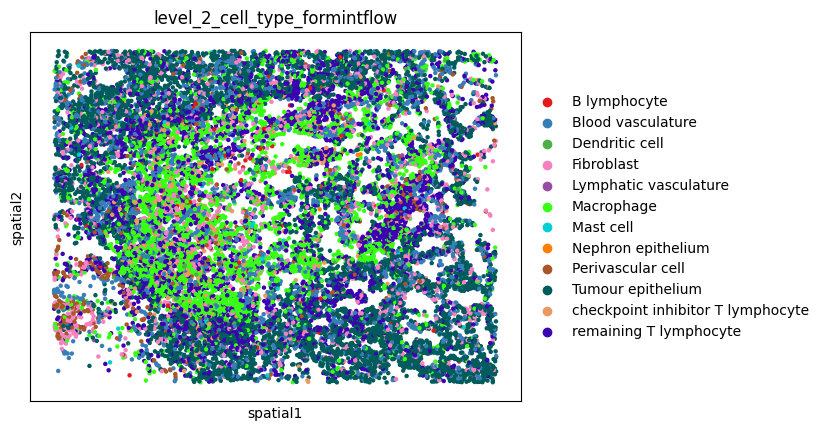

In [5]:
### GENERATES FIGURE 7B

## Set up adata object and regions, tune cropped window size

adata = sc.read_h5ad(
    path_anndata
)
adata_original = adata[
    (adata.obs['x_centroid'] > 1500) &  (adata.obs['x_centroid'] < 3500) &\
    (adata.obs['y_centroid'] > 1000) &  (adata.obs['y_centroid'] < 2500)
].copy()
print(adata)

# Define your custom colors
custom_colors = {
    'B lymphocyte': '#e41a1c',              # red
    'Blood vasculature': '#377eb8',         # blue
    'Dendritic cell': '#4daf4a',            # green
    'Fibroblast': '#f781bf',                # pink
    'Lymphatic vasculature': '#984ea3',     # purple (maroon)
    'Macrophage': '#39ff14',                # 💡 fluorescent green (neon/lime)
    'Mast cell': '#00ced1',                 # turquoise
    'Nephron epithelium': '#ff7f00',        # orange
    'Perivascular cell': '#a65628',         # brown
    'checkpoint inhibitor T lymphocyte': '#ea9a61',  # peach-orange
    'remaining T lymphocyte': '#3b00b2',    # dark blue
    'Tumour epithelium': '#005c5c'          # dark teal-green
}


# Plot using your custom color mapping
sc.pl.spatial(
    adata_original,
    spot_size=20,
    color='level_2_cell_type_formintflow',
    palette=custom_colors
)

In [6]:
# Replace T cell subset

adata_perturbed = adata_original.copy()
adata_perturbed.obs['level_2_cell_type_formintflow'] = adata_perturbed.obs['level_2_cell_type_formintflow'].replace(
    {'remaining T lymphocyte':'checkpoint inhibitor T lymphocyte'}
) 

/tmp/ipykernel_1732421/2819558733.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_perturbed.obs['level_2_cell_type_formintflow'] = adata_perturbed.obs['level_2_cell_type_formintflow'].replace(


In [8]:
## Check cell numbers

adata_perturbed.obs['level_2_cell_type_formintflow'].value_counts()

level_2_cell_type_formintflow
Tumour epithelium                    5039
checkpoint inhibitor T lymphocyte    4296
Macrophage                           2921
Blood vasculature                    2460
Fibroblast                           1378
Perivascular cell                     406
Dendritic cell                        238
B lymphocyte                           84
Mast cell                              34
Lymphatic vasculature                   8
Nephron epithelium                      5
Name: count, dtype: int64

In [ ]:
### GENERATES FIGURE 6B

# Define your custom colors
custom_colors = {
    'B lymphocyte': '#e41a1c',              # red
    'Blood vasculature': '#377eb8',         # blue
    'Dendritic cell': '#4daf4a',            # green
    'Fibroblast': '#f781bf',                # pink
    'Lymphatic vasculature': '#984ea3',     # purple (maroon)
    'Macrophage': '#39ff14',                # 💡 fluorescent green (neon/lime)
    'Mast cell': '#00ced1',                 # turquoise
    'Nephron epithelium': '#ff7f00',        # orange
    'Perivascular cell': '#a65628',         # brown
    'checkpoint inhibitor T lymphocyte': '#ea9a61',  # peach-orange
    'Tumour epithelium': '#005c5c'          # dark teal-green
}

# Plot using your custom color mapping
sc.pl.spatial(
    adata_perturbed,
    spot_size=20,
    color='level_2_cell_type_formintflow',
    palette=custom_colors
)

In [9]:
## Create the neighbourhood graph

kwargs_neighbourhood_graph = {
    'spatial_key': 'spatial',
    'library_key': None,
    'set_diag': False,
    'delaunay': False,
    'n_neighs': 10
}
adata.uns = {}
sq.gr.spatial_neighbors(
    adata=adata_original,
    **kwargs_neighbourhood_graph
)

kwargs_neighbourhood_graph = {
    'spatial_key': 'spatial',
    'library_key': None,
    'set_diag': False,
    'delaunay': False,
    'n_neighs': 10
}
adata_original.uns = {}
adata_perturbed.uns = {}

sq.gr.spatial_neighbors(
    adata=adata_original,
    **kwargs_neighbourhood_graph
)
sq.gr.spatial_neighbors(
    adata=adata_perturbed,
    **kwargs_neighbourhood_graph
)

In [11]:
## Generate predictions for original dataset

result_generation_original = mintflow.generate_insilico_ST_data(
    adata=adata_original,
    obskey_celltype='level_2_cell_type_formintflow',
    obspkey_neighbourhood_graph='spatial_connectivities',
    device=device,
    batch_index_trainingdata=2,
    num_generated_realisations=100,
    model=checkpoint_mintflow['model'],
    data_mintflow=checkpoint_mintflow['data_mintflow'],
    dict_all4_configs=checkpoint_mintflow['dict_all4_configs'],
    estimate_spatial_sizefactors_on_sections=[2]
)

Evaluating on tissue section: 2:   0%|          | 0/59 [00:00<?, ?it/s]

Generating the realisations of the expression data (i.e. generative samples) for the provided in silico tissue…

/nfs/team361/aa36/OnGit/inflow/src/mintflow/generativemodel.py:546: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(edge_index),


In [12]:
## Generate predictions for perturbed dataset

result_generation_perturbed = mintflow.generate_insilico_ST_data(
    adata=adata_perturbed,
    obskey_celltype='level_2_cell_type_formintflow',
    obspkey_neighbourhood_graph='spatial_connectivities',
    device=device,
    batch_index_trainingdata=2,
    num_generated_realisations=100,
    model=checkpoint_mintflow['model'],
    data_mintflow=checkpoint_mintflow['data_mintflow'],
    dict_all4_configs=checkpoint_mintflow['dict_all4_configs'],
    estimate_spatial_sizefactors_on_sections=[2]
)

Evaluating on tissue section: 2:   0%|          | 0/59 [00:00<?, ?it/s]

Generating the realisations of the expression data (i.e. generative samples) for the provided in silico tissue…

/nfs/team361/aa36/OnGit/inflow/src/mintflow/generativemodel.py:546: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(edge_index),


In [13]:
## Create dictionaries to match cell ids

adata_original.obsm['MintFLow_Generated_Xmic'] = np.stack(
    [realisation['MintFLow_Generated_Xmic'] for realisation in result_generation_original['list_generated_realisations_ie_expressions']]
).mean(0)

adata_perturbed.obsm['MintFLow_Generated_Xmic'] = np.stack(
    [realisation['MintFLow_Generated_Xmic'] for realisation in result_generation_perturbed['list_generated_realisations_ie_expressions']]
).mean(0)

list_cellID_original = adata_original.obs['cell_id'].tolist()
list_cellID_perturbed = adata_perturbed.obs['cell_id'].tolist()

dict_cellID_to_indexOriginal = {
    cell_id: list_cellID_original.index(cell_id)
    for cell_id in set(adata_original.obs['cell_id']).union(set(adata_perturbed.obs['cell_id']))
}
dict_cellID_to_indexPerturbed = {
    cell_id: list_cellID_perturbed.index(cell_id)
    for cell_id in set(adata_original.obs['cell_id']).union(set(adata_perturbed.obs['cell_id']))
}

print(adata_original.obs['cell_id'])
print(adata_perturbed.obs['cell_id'])

In [17]:
## Check which cells are perturbed

dict_cellID_to_MCChaschanged = {}
for cell_id in set(adata_original.obs['cell_id']).union(set(adata_perturbed.obs['cell_id'])):
    if (cell_id not in adata_original.obs['cell_id'].tolist()) or (cell_id not in adata_perturbed.obs['cell_id'].tolist()):
         # if the cell is dropped or added during perturbation --> No differential expression on it
        dict_cellID_to_MCChaschanged[cell_id] = False
    else:
        dict_cellID_to_MCChaschanged[cell_id] = np.allclose(
            result_generation_original['np_MCC'][dict_cellID_to_indexOriginal[cell_id]],
            result_generation_perturbed['np_MCC'][dict_cellID_to_indexPerturbed[cell_id]]
        )
        
print("For {} percent of cells, the MCC has changed due to perturbation.".format(
    np.round(
        100.0 * np.mean([v for u, v in dict_cellID_to_MCChaschanged.items()]),
        3
    )
))

In [19]:
# SAVE DATASETS

adata_original.write("/nfs/team361/dj17/MintFlowPertubation_Tcellvalidation/outputs_v1/adata_original.h5ad")

adata_perturbed.write("/nfs/team361/dj17/MintFlowPertubation_Tcellvalidation/outputs_v1/adata_perturbed.h5ad")


In [20]:
# LOAD DATASETS

#adata_original = sc.read_h5ad("/nfs/team361/dj17/MintFlowPertubation_Tcellvalidation/outputs_v1/adata_original.h5ad")
#adata_perturbed = sc.read_h5ad("/nfs/team361/dj17/MintFlowPertubation_Tcellvalidation/outputs_v1/adata_perturbed.h5ad")

In [21]:
print(adata_original)
print(adata_perturbed)

AnnData object with n_obs × n_vars = 16869 × 5001
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', '_scvi_batch', '_scvi_labels', 'SCVI_CLUSTERS_KEY', 'cell_area_highlight', 'low_quality_cell_highlight', 'level_1_cell_type', 'level_2_cell_type', 'level_3_cell_type', 'level_2_cell_type_formintflow', 'TissueSectionID_for_MintFlow', 'batchID_for_MintFlow'
    uns: 'spatial_neighbors'
    obsm: 'X_scVI', 'X_umap', 'spatial', 'MintFLow_Generated_Xmic'
    layers: 'X_by_Dan'
    obsp: 'spatial_connectivities', 'spatial_distances'
AnnData object with n_obs × n_vars = 1686

In [22]:
## Double check which cell types have been perturbed

for ct in set(adata_perturbed.obs['level_2_cell_type_formintflow']):
    row_filter_original = np.logical_and(
        np.array(adata_original.obs['level_2_cell_type_formintflow']  == ct),  # filter based on cell type
        np.array([
            dict_cellID_to_MCChaschanged[cell_id]
            for cell_id in adata_original.obs['cell_id'].tolist()
        ])  # filter based on if MCC vector has changed
    )
    row_filter_perturbed = np.logical_and(
        np.array(adata_perturbed.obs['level_2_cell_type_formintflow']  == ct),  # filter based on cell type
        np.array([
            dict_cellID_to_MCChaschanged[cell_id]
            for cell_id in adata_perturbed.obs['cell_id'].tolist()
        ])  # filter based on if MCC vector has changed
    )
    print("For cell type {} filtered {} cells from orig and {} cells from modif.".format(ct, np.sum(row_filter_original), np.sum(row_filter_perturbed)))

For cell type Perivascular cell filtered 82 cells from orig and 82 cells from modif.
For cell type B lymphocyte filtered 5 cells from orig and 5 cells from modif.
For cell type Nephron epithelium filtered 1 cells from orig and 1 cells from modif.
For cell type Macrophage filtered 294 cells from orig and 294 cells from modif.
For cell type checkpoint inhibitor T lymphocyte filtered 30 cells from orig and 306 cells from modif.
For cell type Fibroblast filtered 270 cells from orig and 270 cells from modif.
For cell type Lymphatic vasculature filtered 1 cells from orig and 1 cells from modif.
For cell type Dendritic cell filtered 5 cells from orig and 5 cells from modif.
For cell type Tumour epithelium filtered 1151 cells from orig and 1151 cells from modif.
For cell type Mast cell filtered 6 cells from orig and 6 cells from modif.
For cell type Blood vasculature filtered 465 cells from orig and 465 cells from modif.


/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


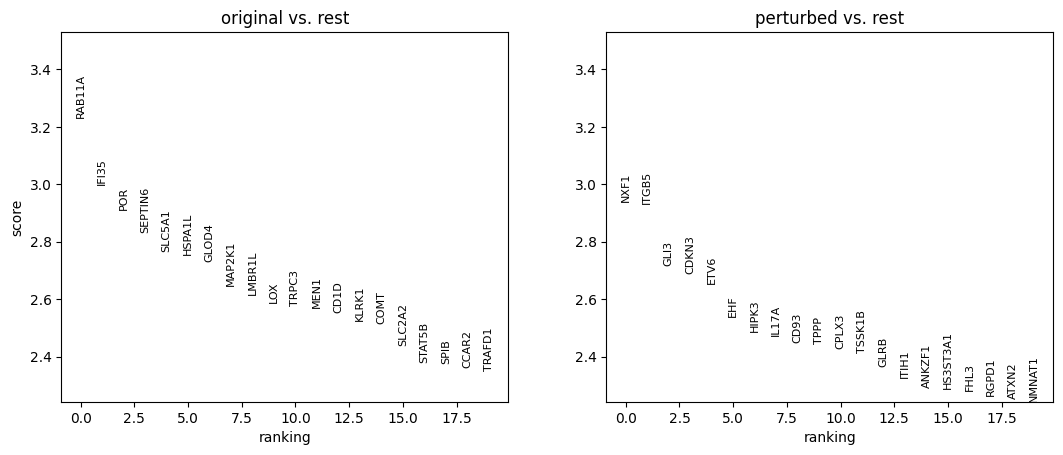

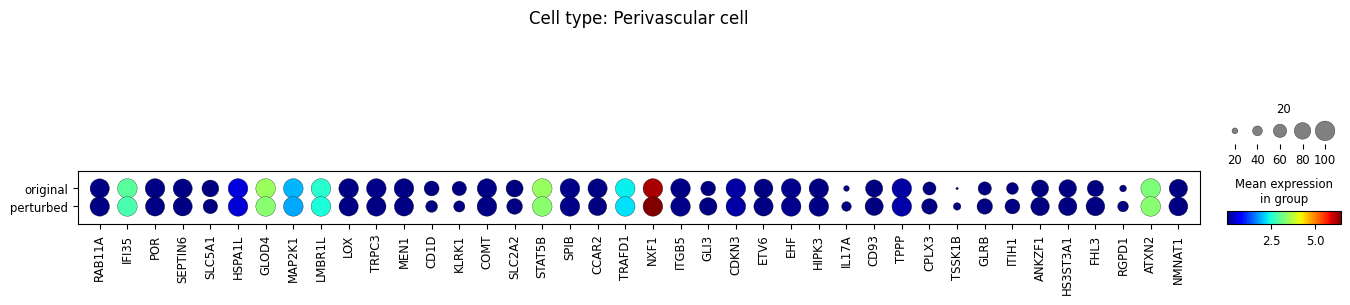

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


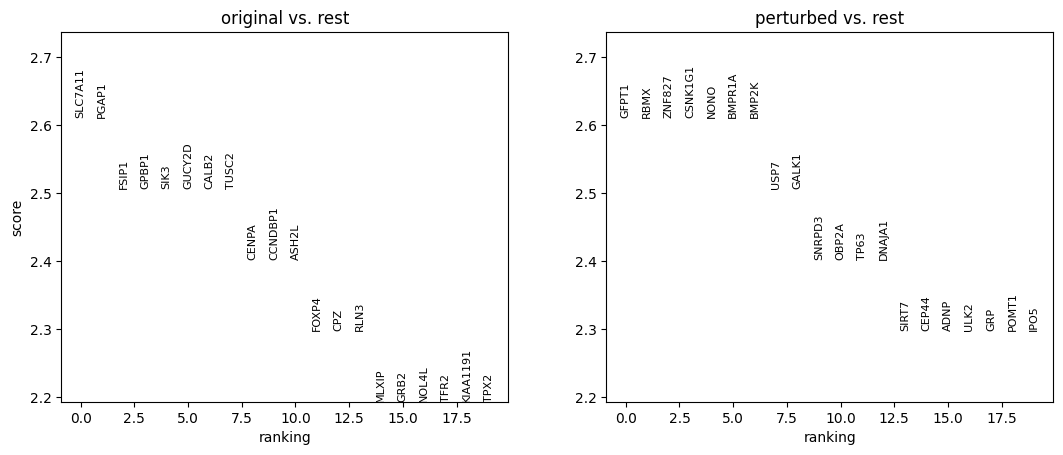

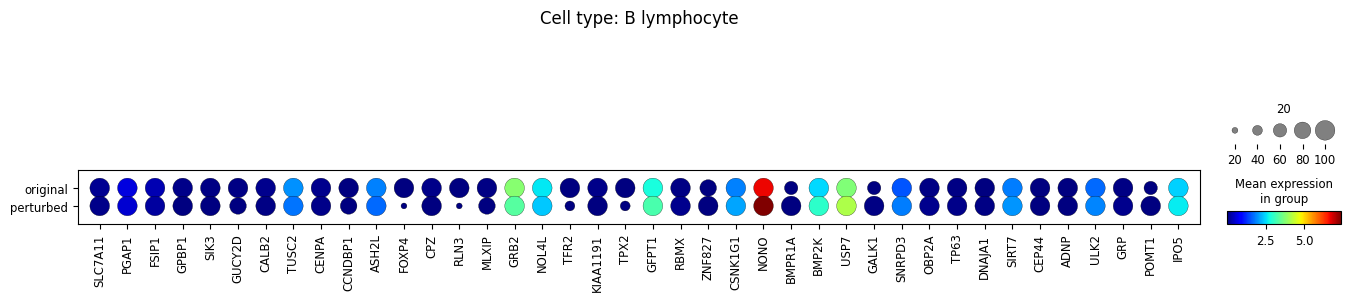

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


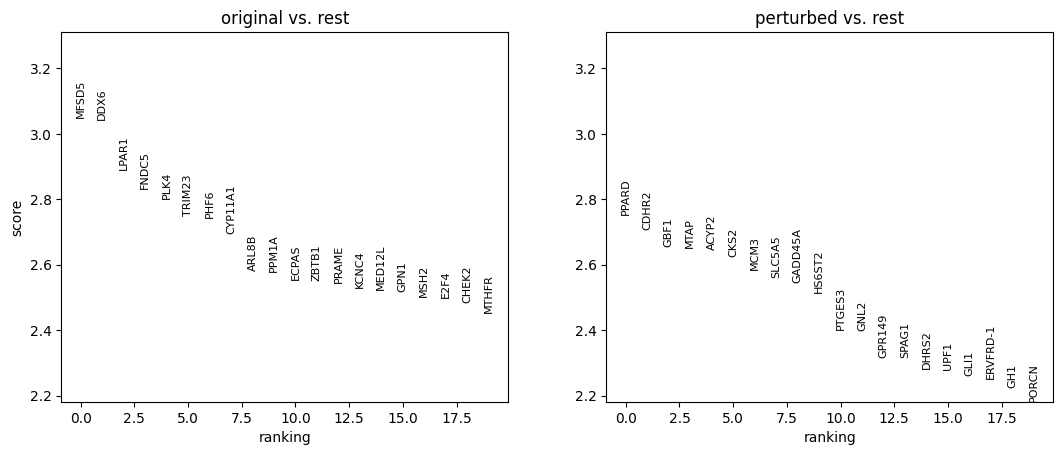

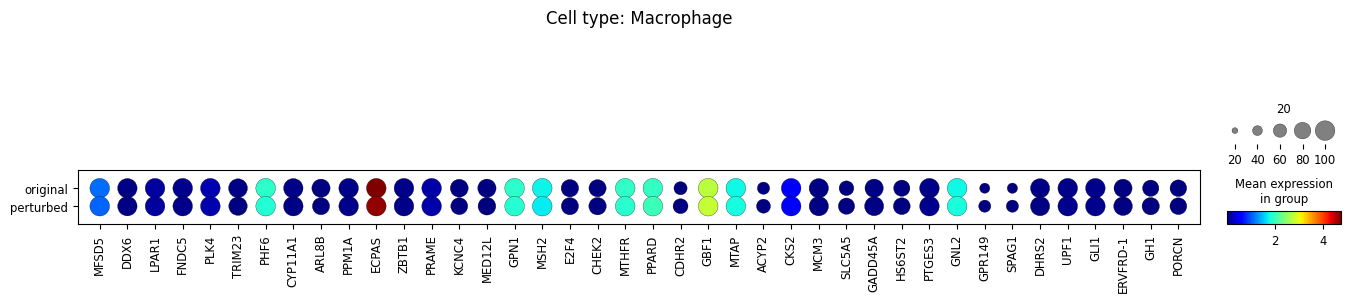

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


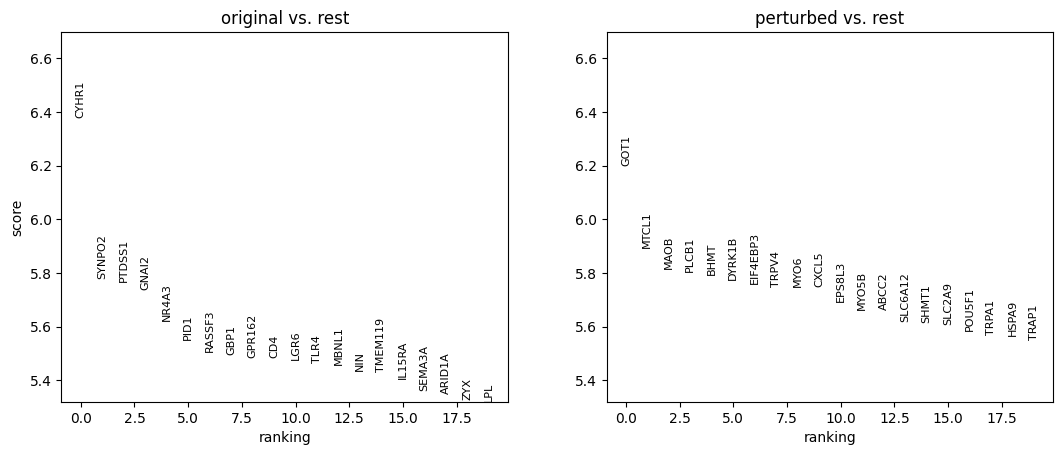

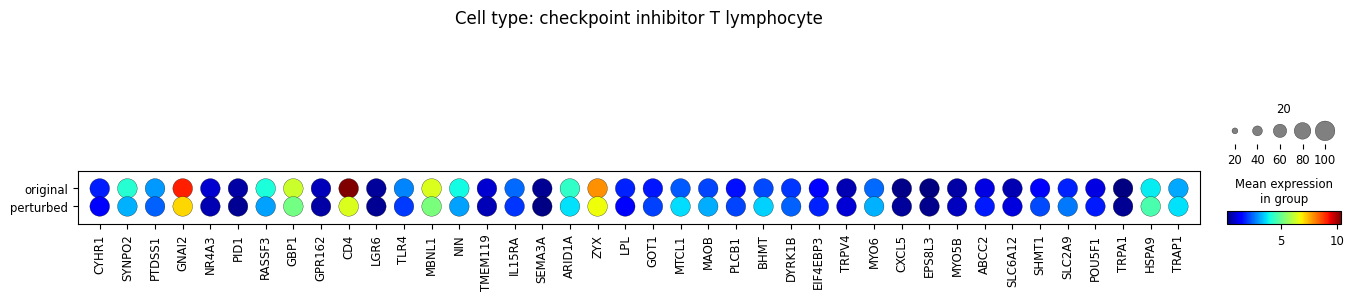

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


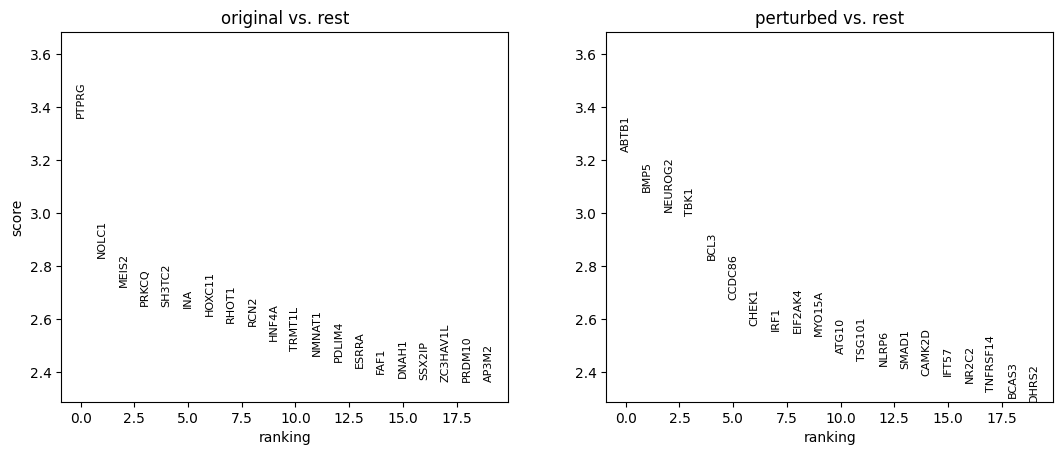

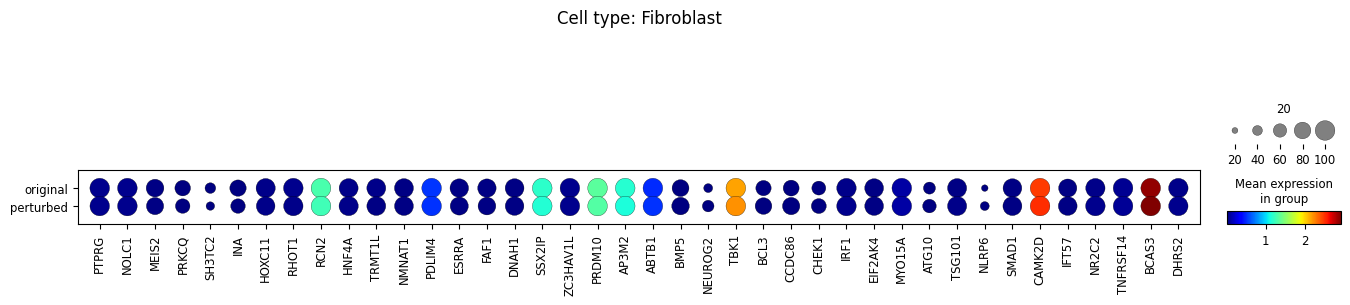

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


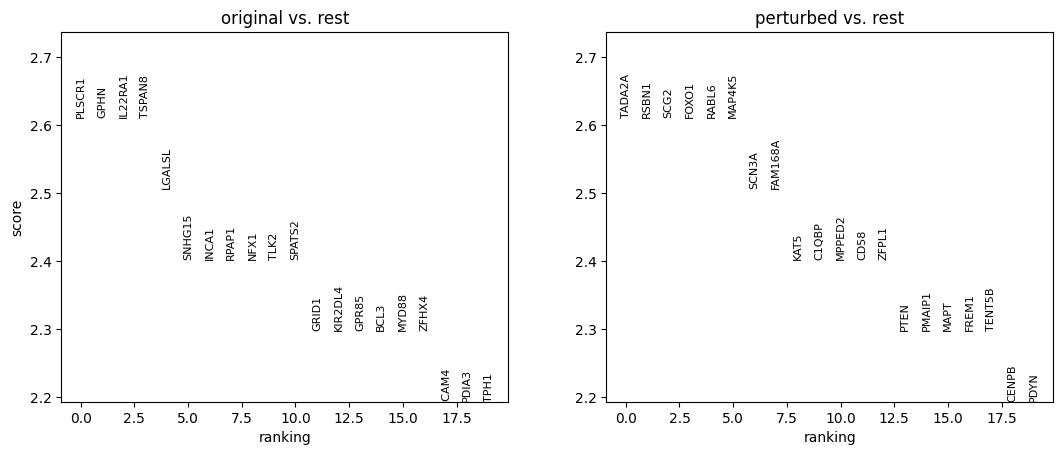

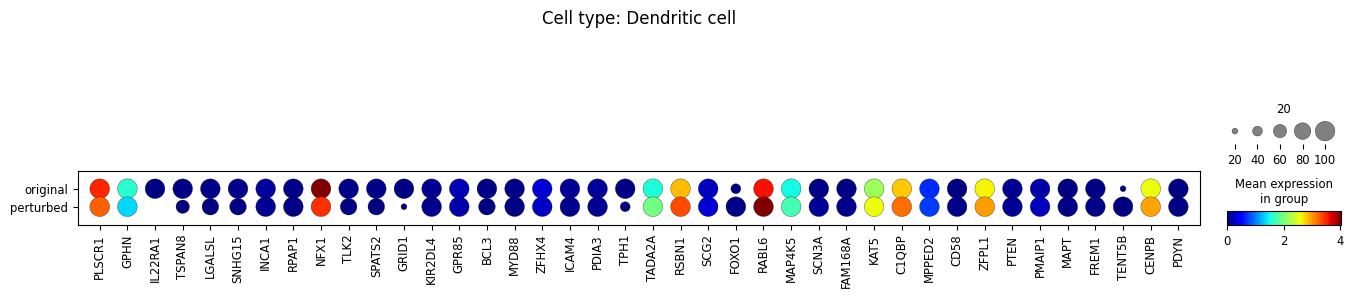

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


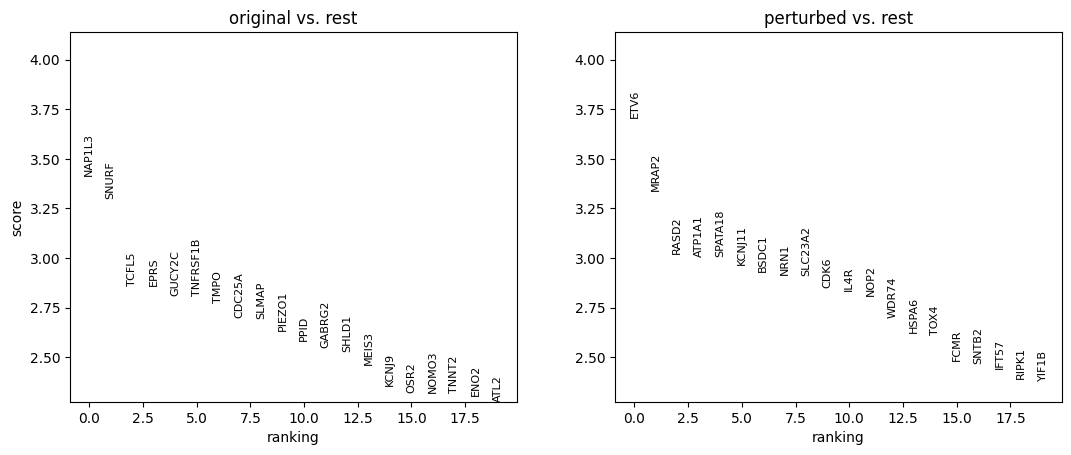

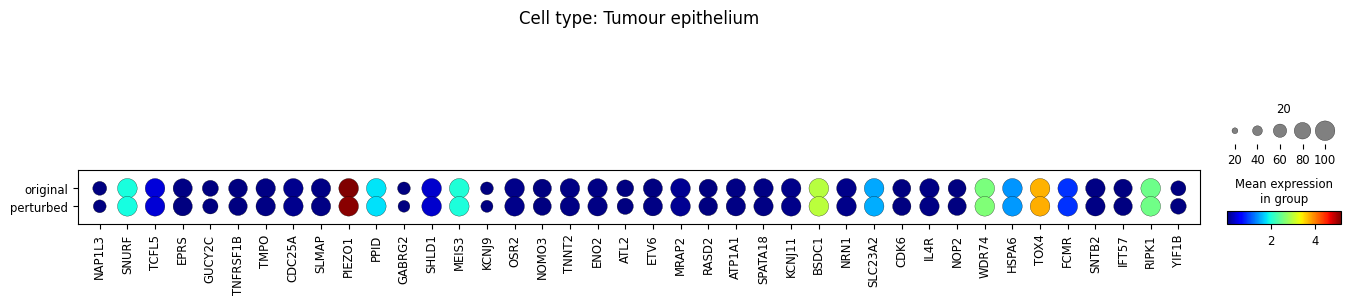

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


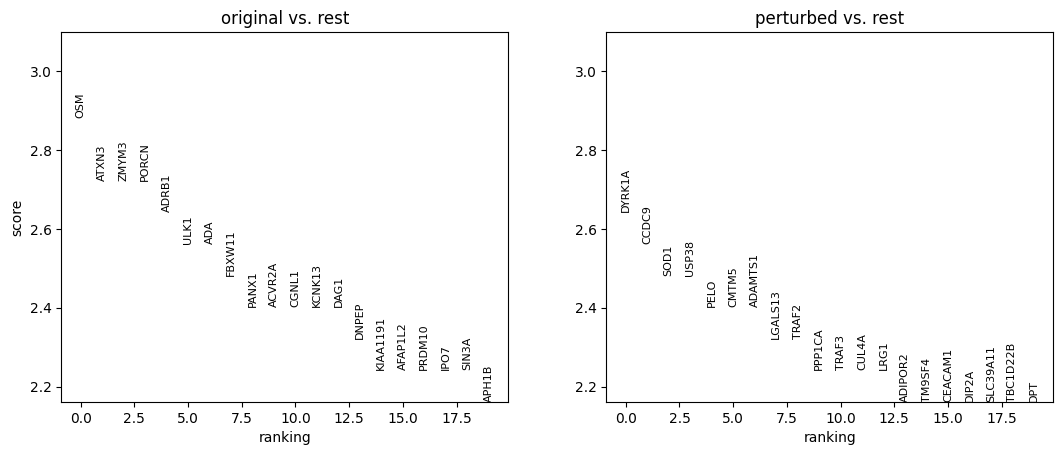

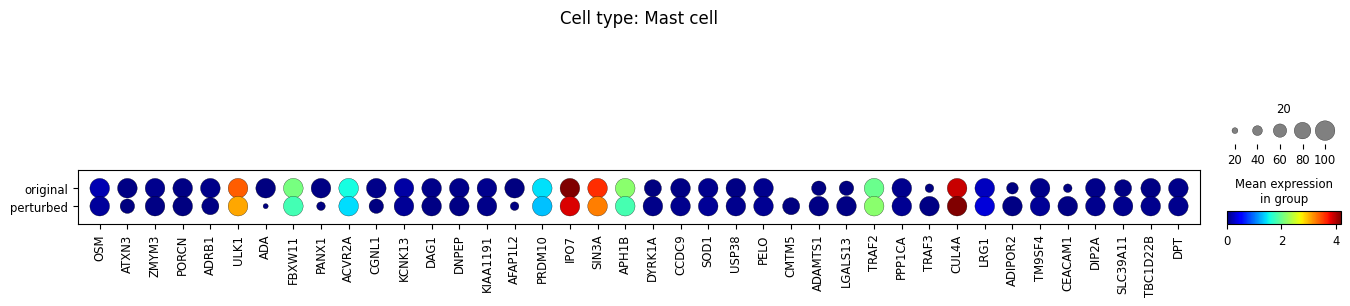

/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


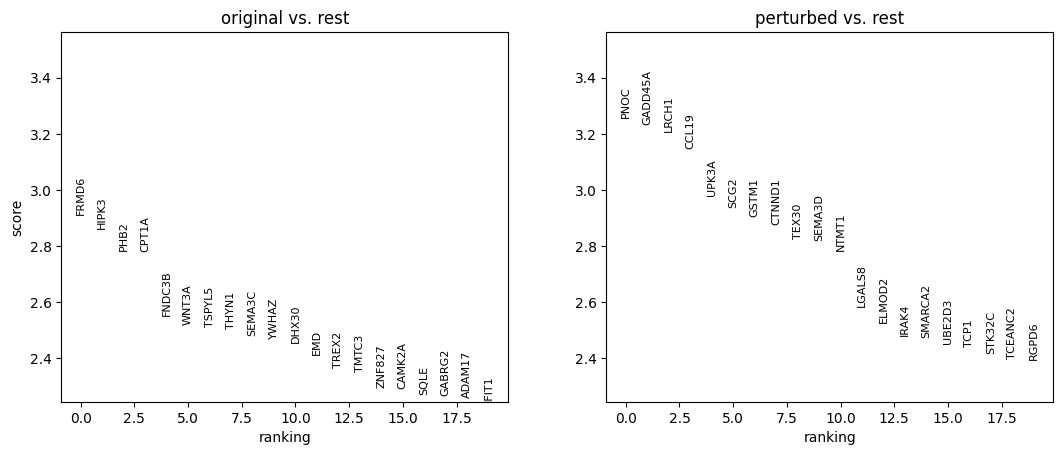

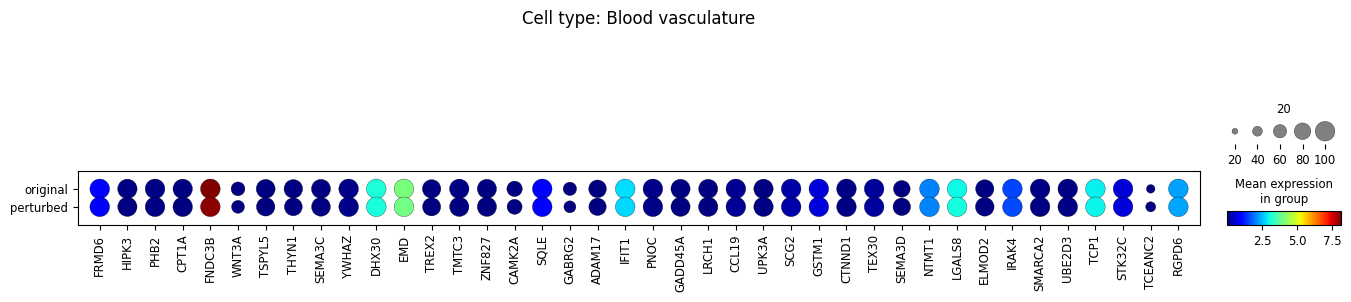

In [24]:
## Original script by Akbar by subsetting to MCC-changed cells and doing differential expression across cell types

for ct in set(adata_perturbed.obs['level_2_cell_type_formintflow']):
    row_filter_original = np.logical_and(
        np.array(adata_original.obs['level_2_cell_type_formintflow']  == ct),  # filter based on cell type
        np.array([
            dict_cellID_to_MCChaschanged[cell_id]
            for cell_id in adata_original.obs['cell_id'].tolist()
        ])  # filter based on if MCC vector has changed
    )
    row_filter_perturbed = np.logical_and(
        np.array(adata_perturbed.obs['level_2_cell_type_formintflow']  == ct),  # filter based on cell type
        np.array([
            dict_cellID_to_MCChaschanged[cell_id]
            for cell_id in adata_perturbed.obs['cell_id'].tolist()
        ])  # filter based on if MCC vector has changed
    )
    
    

    if np.sum(np.logical_and(row_filter_original, row_filter_perturbed)) <= 2:
        continue  # not enough cells --> skip the DE analysis

    # make an anndata for DE analysis
    adata_DEanalysis = sc.AnnData(
        X=np.concatenate(
            [adata_original.obsm['MintFLow_Generated_Xmic'][row_filter_original.tolist()] + 0.0,
             adata_perturbed.obsm['MintFLow_Generated_Xmic'][row_filter_perturbed.tolist()] + 0.0],
            0
        ),
        obs=pd.DataFrame(
            data=np.array(
                [sum(row_filter_original)*['original'] +\
                 sum(row_filter_perturbed)*['perturbed']]
            ).T,
            columns=['original_vs_perturbed']
        ),
        var=adata_original.var
    )


    # perform the DE analysis
    adata_DEanalysis.layers['xspl_before_log1p'] = adata_DEanalysis.X.copy()
    sc.pp.log1p(adata_DEanalysis)

    sc.tl.rank_genes_groups(
        adata_DEanalysis,
        'original_vs_perturbed',
        method='wilcoxon',
        n_genes=20
    )
    sc.pl.rank_genes_groups(adata_DEanalysis)
    sc.pl.dotplot(
        adata_DEanalysis,
        var_names=\
        [u[0] for u in adata_DEanalysis.uns['rank_genes_groups']['names'].tolist()]+\
        [u[1] for u in adata_DEanalysis.uns['rank_genes_groups']['names'].tolist()],
        groupby='original_vs_perturbed',
        dendrogram=True,
        title="Cell type: {}".format(ct),
        size_title=20,
        cmap='jet',
        layer='xspl_before_log1p',
        mean_only_expressed=True
    )

⚠️ Warning: these genes were not found and will be skipped: {'IGSF6', 'NAPSB', 'FGL2', 'SIGLEC10', 'TMIGD3', 'MNDA', 'CLEC4E', 'ANKRD22', 'SECTM1', 'CALHM6', 'HLA-DQB2'}


/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


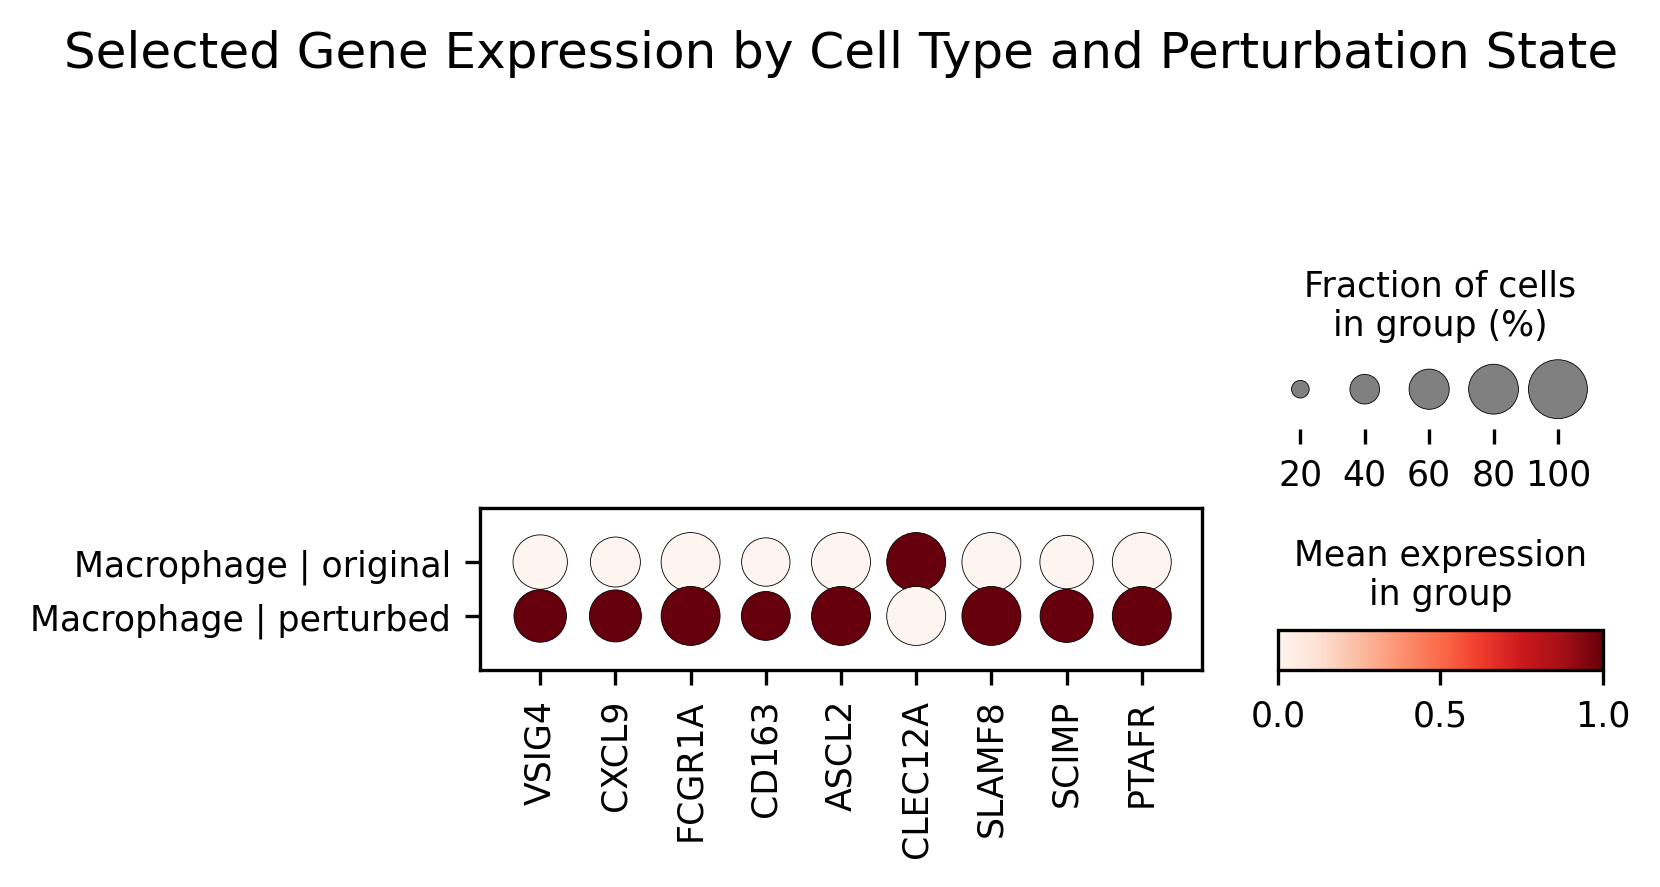

In [63]:
### GENERATES FIGURE 6C

## Macrophage DEGs of interest. Post treatment signature genes derived from this dataset: https://www.sciencedirect.com/science/article/pii/S1535610821001173

# Choose cell types and genes of interest
selected_cell_types = ['Macrophage']
selected_genes = ['VSIG4', 'CXCL9', 'SIGLEC10', 'FCGR1A', 'TMIGD3', 'NAPSB',
    'CALHM6', 'CD163', 'ASCL2', 'CLEC12A', 'SECTM1', 'SLAMF8', 'SCIMP',
    'CLEC4E', 'PTAFR', 'MNDA', 'FGL2', 'HLA-DQB2', 'ANKRD22', 'IGSF6'
]

# Loop and build filtered data
X_data = []
perturbation_labels = []
cell_type_labels = []

for ct in selected_cell_types:
    row_filter_original = np.logical_and(
        adata_original.obs['level_2_cell_type_formintflow'] == ct,
        np.array([
            dict_cellID_to_MCChaschanged.get(cell_id, False)
            for cell_id in adata_original.obs['cell_id'].tolist()
        ])
    )

    row_filter_perturbed = np.logical_and(
        adata_perturbed.obs['level_2_cell_type_formintflow'] == ct,
        np.array([
            dict_cellID_to_MCChaschanged.get(cell_id, False)
            for cell_id in adata_perturbed.obs['cell_id'].tolist()
        ])
    )

    if np.sum(row_filter_original) < 2 or np.sum(row_filter_perturbed) < 2:
        continue

    # Add original cells
    X_data.append(adata_original.obsm['MintFLow_Generated_Xmic'][row_filter_original.tolist()] + 0.0)
    perturbation_labels.extend(['original'] * np.sum(row_filter_original))
    cell_type_labels.extend([ct] * np.sum(row_filter_original))

    # Add perturbed cells
    X_data.append(adata_perturbed.obsm['MintFLow_Generated_Xmic'][row_filter_perturbed.tolist()] + 0.0)
    perturbation_labels.extend(['perturbed'] * np.sum(row_filter_perturbed))
    cell_type_labels.extend([ct] * np.sum(row_filter_perturbed))

# Create AnnData
adata_DEanalysis = sc.AnnData(
    X=np.concatenate(X_data, axis=0),
    obs=pd.DataFrame({
        'perturbation_state': perturbation_labels,
        'cell_type': cell_type_labels
    }),
    var=adata_original.var.copy()
)

# Add combined label for plotting
adata_DEanalysis.obs['celltype_condition'] = (
    adata_DEanalysis.obs['cell_type'] + " | " + adata_DEanalysis.obs['perturbation_state']
)

# Filter genes to those that exist
genes_to_plot = [g for g in selected_genes if g in adata_DEanalysis.var_names]

# Warn if any selected genes are missing
missing_genes = set(selected_genes) - set(genes_to_plot)
if missing_genes:
    print(f"⚠️ Warning: these genes were not found and will be skipped: {missing_genes}")

# Plot
sc.pl.dotplot(
    adata_DEanalysis,
    var_names=genes_to_plot,
    groupby='celltype_condition',
    standard_scale='var',
    layer=None,  # or 'xspl_before_log1p' if you've logged elsewhere
    cmap='Reds',
    title='Selected Gene Expression by Cell Type and Perturbation State'
)

In [50]:
## Setup for violin plots

# Define gene list
macrophage_genes = ['VSIG4', 'CXCL9', 'SIGLEC10', 'FCGR1A', 'TMIGD3', 'NAPSB',
    'CALHM6', 'CD163', 'ASCL2', 'CLEC12A', 'SECTM1', 'SLAMF8', 'SCIMP',
    'CLEC4E', 'PTAFR', 'MNDA', 'FGL2', 'HLA-DQB2', 'ANKRD22', 'IGSF6'
]

# Subset macrophages with changed MCC
ct = 'Macrophage'
row_filter_original = np.logical_and(
    adata_original.obs['level_2_cell_type_formintflow'] == ct,
    np.array([
        dict_cellID_to_MCChaschanged.get(cell_id, False)
        for cell_id in adata_original.obs['cell_id'].tolist()
    ])
)

row_filter_perturbed = np.logical_and(
    adata_perturbed.obs['level_2_cell_type_formintflow'] == ct,
    np.array([
        dict_cellID_to_MCChaschanged.get(cell_id, False)
        for cell_id in adata_perturbed.obs['cell_id'].tolist()
    ])
)

# Optional: Check counts
print("Original (filtered):", np.sum(row_filter_original))
print("Perturbed (filtered):", np.sum(row_filter_perturbed))

# Step 3: Build AnnData
adata_macrophage = sc.AnnData(
    X=np.concatenate(
        [
            adata_original.obsm['MintFLow_Generated_Xmic'][row_filter_original] + 0.0,
            adata_perturbed.obsm['MintFLow_Generated_Xmic'][row_filter_perturbed] + 0.0
        ],
        axis=0
    ),
    obs=pd.DataFrame({
        'perturbation_state': ['original'] * np.sum(row_filter_original) +
                              ['perturbed'] * np.sum(row_filter_perturbed),
        'cell_type': [ct] * (np.sum(row_filter_original) + np.sum(row_filter_perturbed))
    }),
    var=adata_original.var.copy()
)

# Step 4: Check gene presence
genes_to_plot = [g for g in macrophage_genes if g in adata_macrophage.var_names]
missing = set(macrophage_genes) - set(genes_to_plot)
if missing:
    print("Missing genes:", missing)

# Step 5: Make perturbation_state categorical
adata_macrophage.obs['perturbation_state'] = adata_macrophage.obs['perturbation_state'].astype('category')


Original (filtered): 294
Perturbed (filtered): 294
⚠️ Missing genes: {'IGSF6', 'NAPSB', 'FGL2', 'SIGLEC10', 'TMIGD3', 'MNDA', 'CLEC4E', 'ANKRD22', 'SECTM1', 'CALHM6', 'HLA-DQB2'}


/nfs/team361/aa36/PythonEnvs_2/envinflowdec27/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


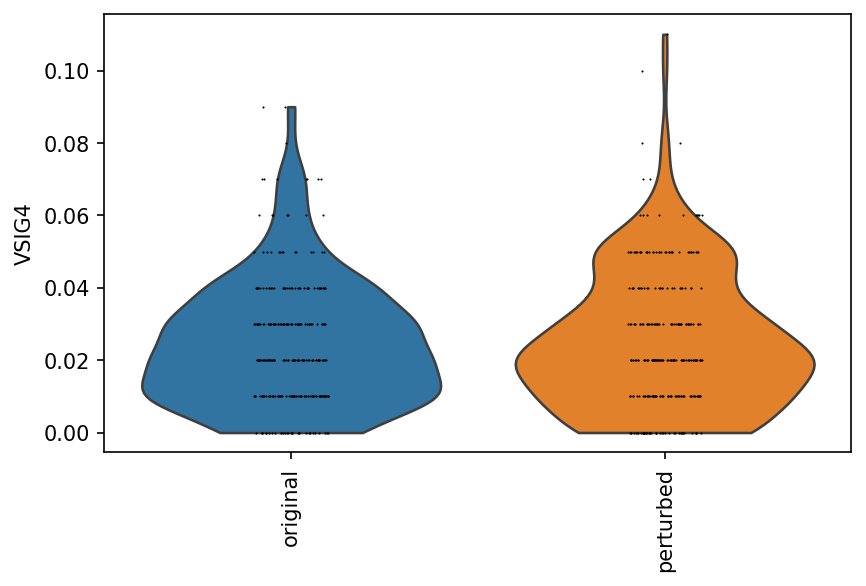

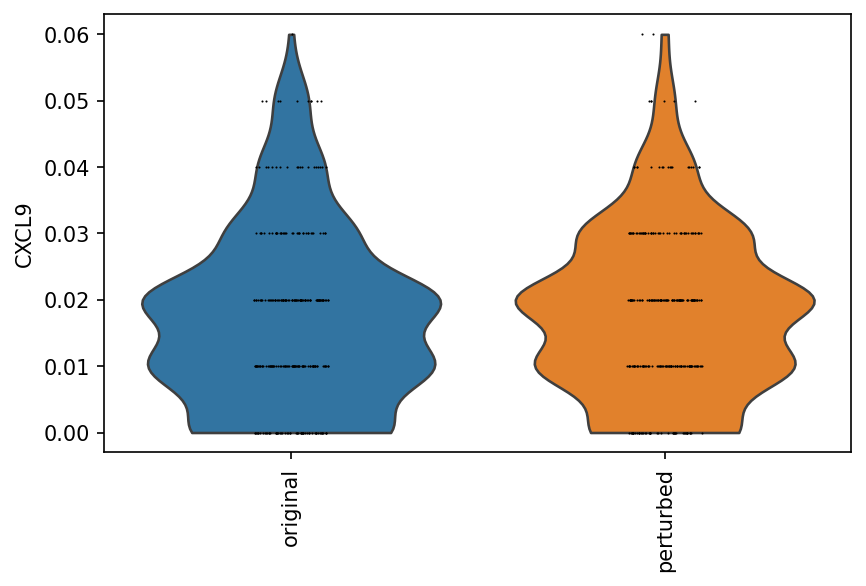

⚠️ Gene not found in var_names: SIGLEC10


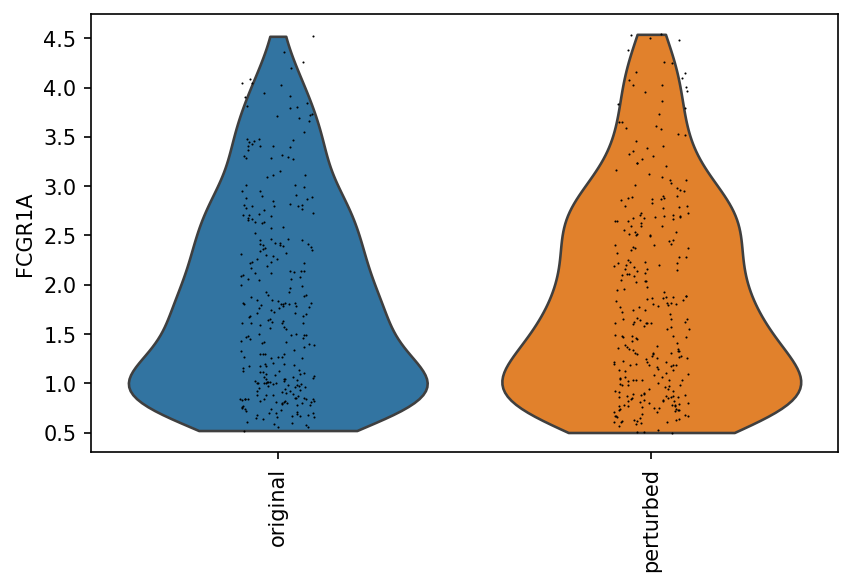

⚠️ Gene not found in var_names: TMIGD3
⚠️ Gene not found in var_names: NAPSB
⚠️ Gene not found in var_names: CALHM6


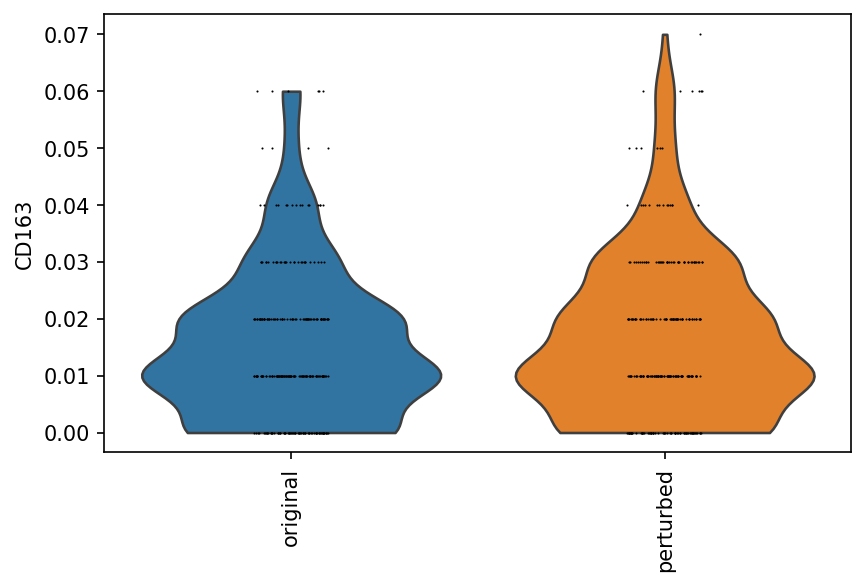

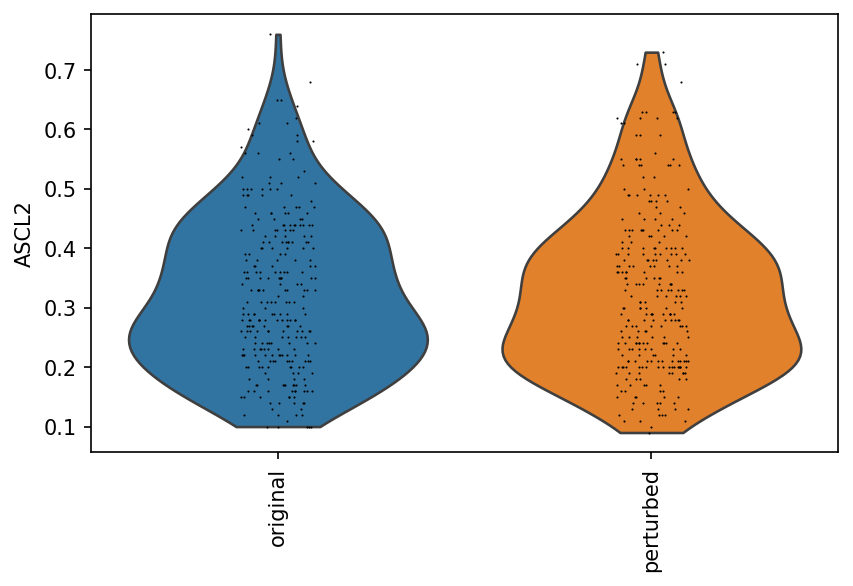

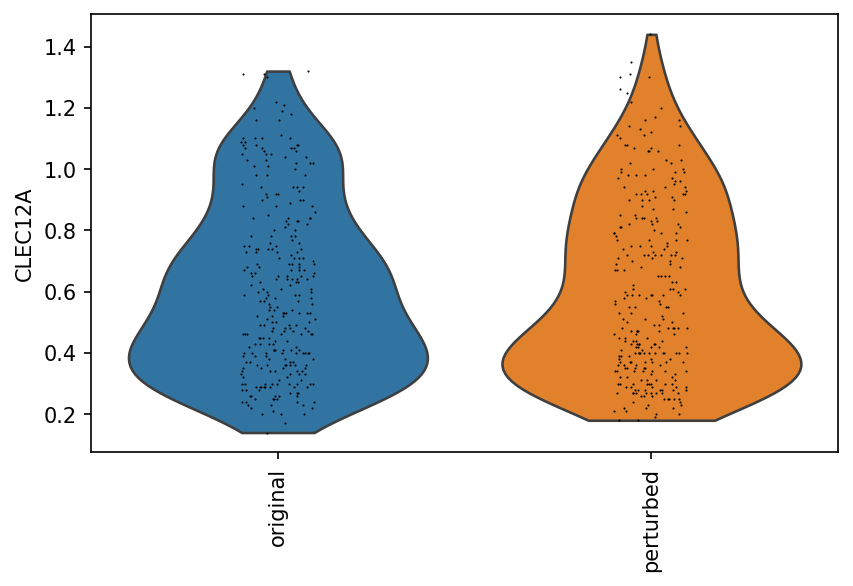

⚠️ Gene not found in var_names: SECTM1


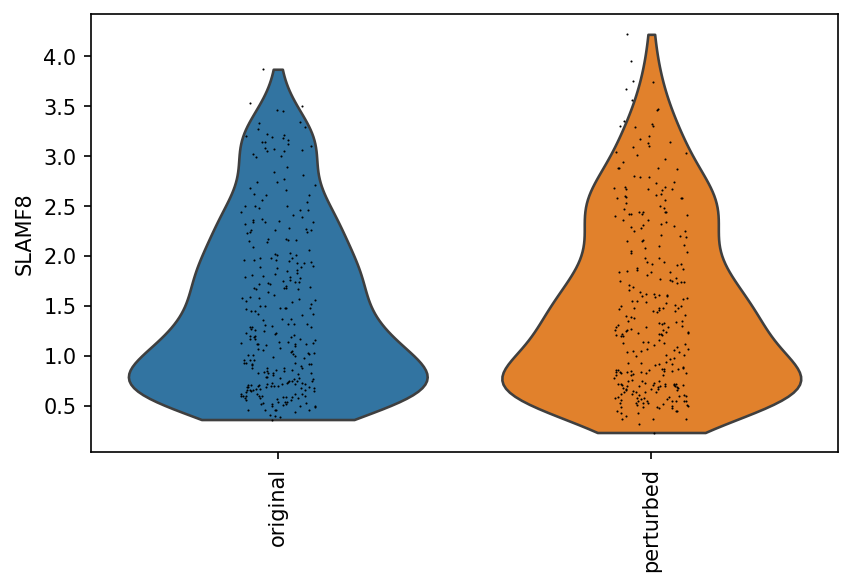

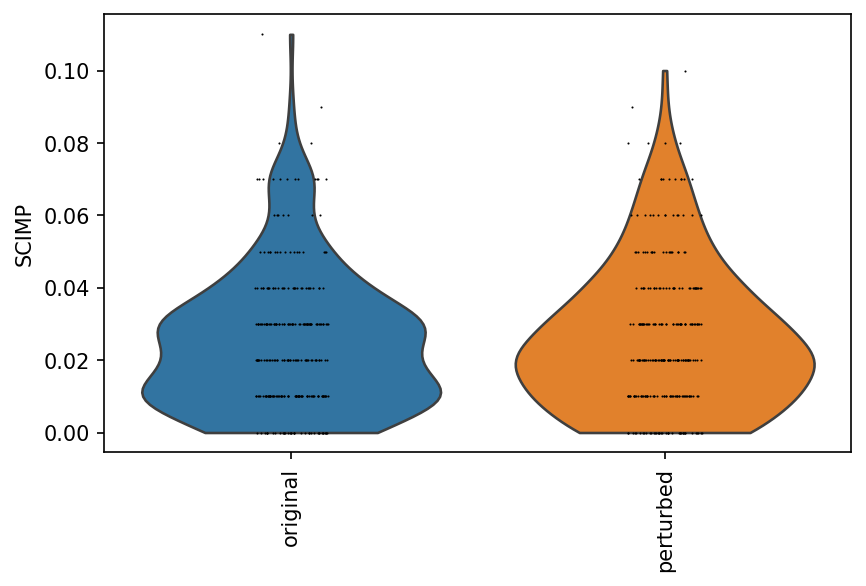

⚠️ Gene not found in var_names: CLEC4E


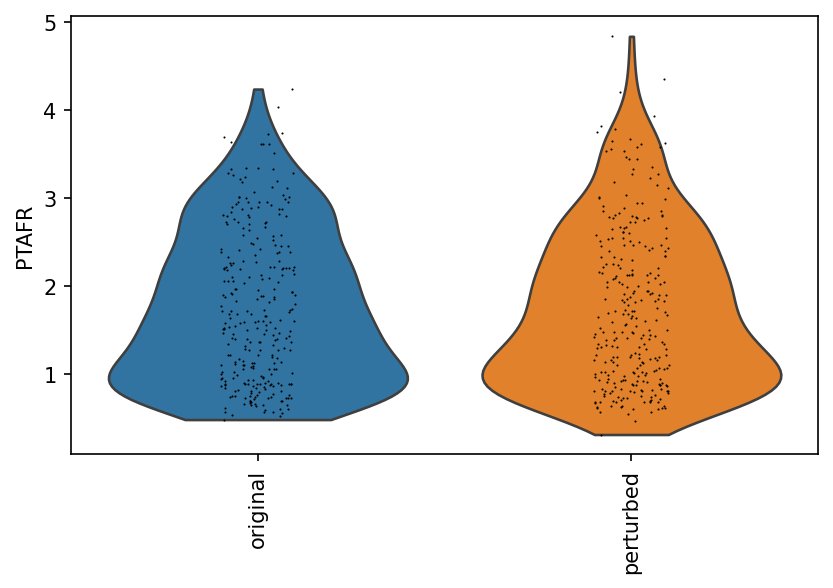

⚠️ Gene not found in var_names: MNDA
⚠️ Gene not found in var_names: FGL2
⚠️ Gene not found in var_names: HLA-DQB2
⚠️ Gene not found in var_names: ANKRD22
⚠️ Gene not found in var_names: IGSF6


In [69]:
## Execute for violin plots (for sanity checking, not included in paper)

plt.rcParams["figure.figsize"] = (3, 2)  # width, height in inches
plt.rcParams["figure.dpi"] = 300  # high resolution for export

# Set global figure size and DPI for better visuals
plt.rcParams["figure.figsize"] = (6, 4)  # Adjust as needed
plt.rcParams["figure.dpi"] = 150

# Loop through genes and generate violin plots
for gene in macrophage_genes:
    if gene in adata_macrophage.var_names:
        sc.pl.violin(
            adata_macrophage,
            keys=gene,
            groupby='perturbation_state',
            stripplot=True,
            jitter=True,
            rotation=90,
            multi_panel=False,
            show=True
        )
    else:
        print(f"Gene not found in var_names: {gene}")

/tmp/ipykernel_1732421/3055806562.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


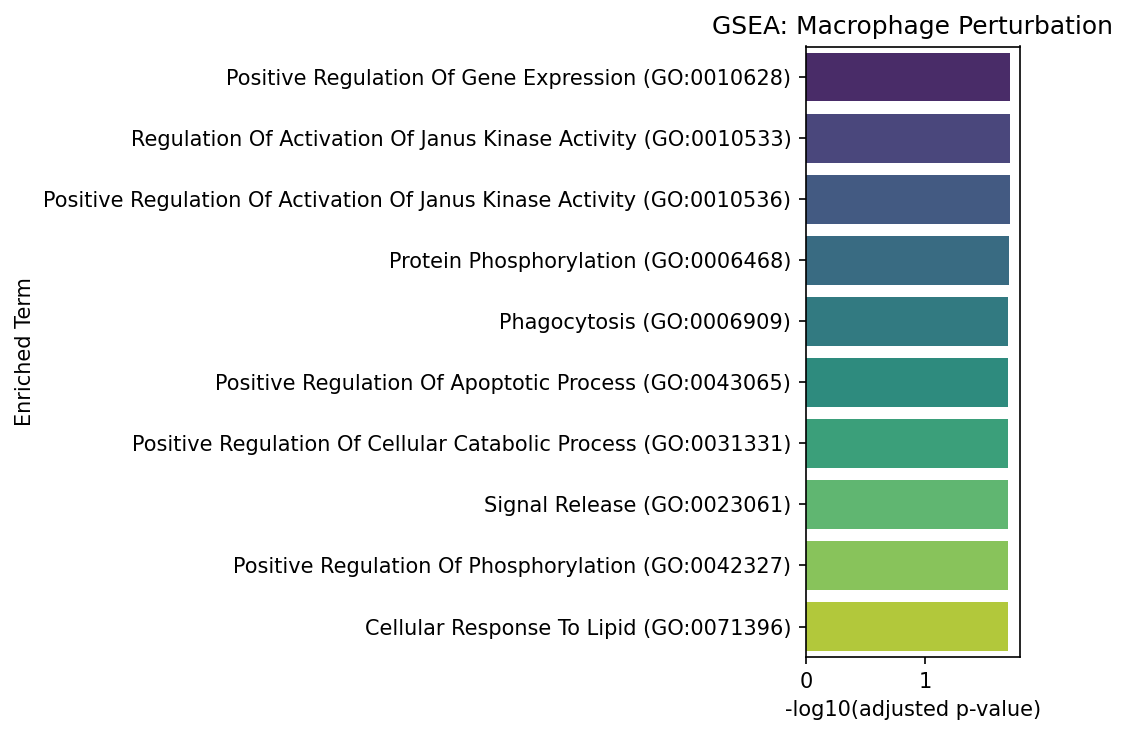

In [86]:
## GENERATES FIGURE SUPPLEMENTARY S14

## GSEA analysis of genes changes within macrophages after perturbation

# Log1p transform
adata_macrophage.layers['log1p_X'] = np.log1p(adata_macrophage.X.copy())

# Run DE using Wilcoxon test
sc.tl.rank_genes_groups(
    adata_macrophage,
    groupby='perturbation_state',
    reference='original',
    method='wilcoxon',
    use_raw=False,
    layer='log1p_X')

# Get DE results for the perturbed group
de_df = sc.get.rank_genes_groups_df(adata_macrophage, group='perturbed')

# You can filter further if needed
top_genes = de_df['names'].tolist()[:200]

# Enrichment using Enrichr Reactome library
enr = gp.enrichr(
    gene_list=top_genes,
    gene_sets='GO_Biological_Process_2023',
    organism='Human',
    outdir=None,
    cutoff=0.05  # filter on adjusted p-value
)

# Make a copy of the results
res_df = enr.res2d.copy()

# Create a new column for –log10(p-value)
res_df['log10_pval'] = -np.log10(res_df['Adjusted P-value'])

# Sort by significance
res_df = res_df.sort_values('log10_pval', ascending=False).head(10)

# Plot
plt.figure(figsize=(7, 5))
sns.barplot(
    x='log10_pval',
    y='Term',
    data=res_df,
    palette='viridis'
)
plt.xlabel('-log10(adjusted p-value)')
plt.ylabel('Enriched Term')
plt.title('GSEA: Macrophage Perturbation')
plt.tight_layout()
plt.show()
